In [ ]:
import warnings
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import MDAnalysis as mda
import numpy as np
import pandas as pd
from MDAnalysis.analysis.dihedrals import Ramachandran
from MDAnalysis.analysis.distances import distance_array
from MDAnalysis.analysis.dssp import DSSP
from MDAnalysis.analysis.rms import RMSD, RMSF

warnings.filterwarnings("ignore", category=UserWarning, module="MDAnalysis")

Insert your trajectory file:

In [2]:
WORKDIR = Path.cwd()
trajectory_file = WORKDIR / "output" / "G3_smol_model_0_output.pdb"
log_file = WORKDIR / "output" / "G3_smol_model_0_log.txt"

Visualize the energy throughout the trajectory. If the curve stabilize to a horizontal line during the simulation, it is assumed to be converged.

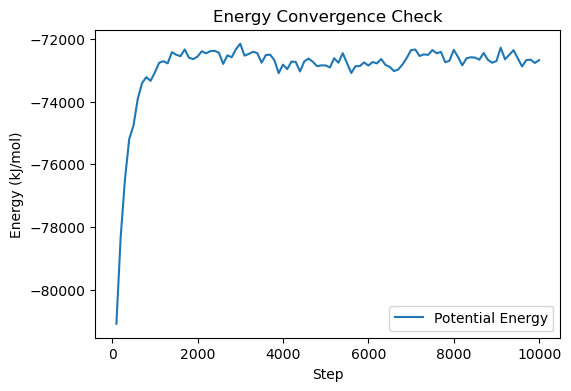

In [3]:
# Plot energy convergence from the log file
df = pd.read_csv(log_file, header=0)
df.columns = [c.lstrip("#").strip('"') for c in df.columns]

plt.figure(figsize=(6, 4))
plt.plot(df["Step"], df["Potential Energy (kJ/mole)"], label="Potential Energy")
plt.xlabel("Step")
plt.ylabel("Energy (kJ/mol)")
plt.legend()
plt.title("Energy Convergence Check")
plt.show()

Based on the convergence plot, choose the starting frame for the upcoming analysis plots. If you do want to look at the whole trajectory, choose `0`.

Note that you need to define the `frame` of the output trajectory, not the `step` that is shown in the energy convergence plot! If you wrote a trajectory frame every 100 step, you need to devide the step number by 100.
E.g. In the plot above, a decent cutoff would be around `step 2000`. This trajectory was recorded one `frame` every `100 steps`. So `start_frame` should be `20`.

In [4]:
start_frame = 20

Next we plot the RMSD compared to the initial structure:

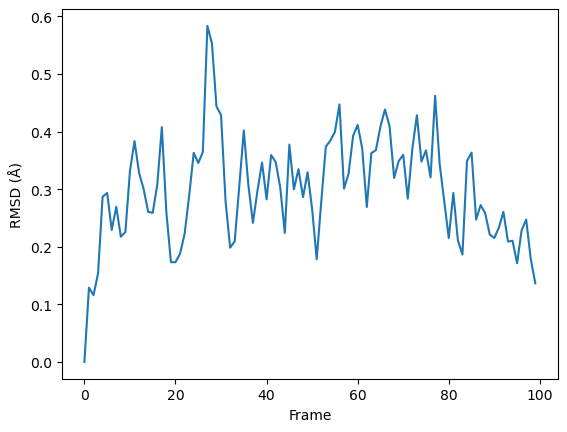

In [5]:
# https://docs.mdanalysis.org/1.1.1/documentation_pages/analysis/rms.html
u = mda.Universe(str(trajectory_file))
rmsd = RMSD(u, u, select="backbone").run()

plt.plot(rmsd.results.rmsd[:, 1], rmsd.results.rmsd[:, 2])
plt.xlabel("Frame")
plt.ylabel("RMSD (Å)")
plt.show()

We can also visualize the RMS per residue, as the RMSF. This shows flexible and rigid residues.

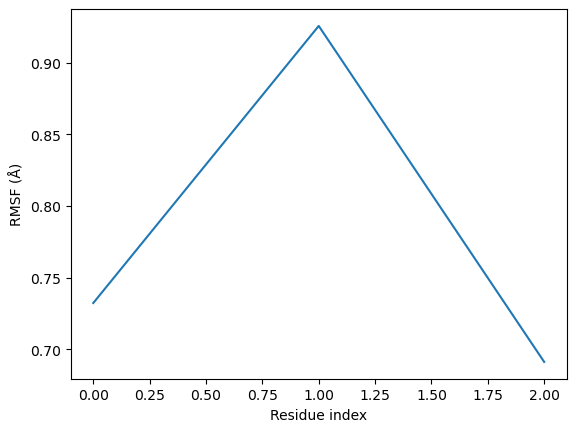

In [6]:
protein = u.select_atoms("protein")
calphas = protein.select_atoms("name CA")
rmsf = RMSF(calphas).run(start=start_frame)

plt.plot(rmsf.results.rmsf)
plt.xlabel("Residue index")
plt.ylabel("RMSF (Å)")
plt.show()

We can show, which parts of the sequence are folded in alpha helices, beta sheets or unfolded.

In [ ]:
# https://docs.mdanalysis.org/dev/documentation_pages/analysis/dssp.html
dssp = DSSP(u).run()
ss = dssp.results.dssp[0]

mapping = {"H": 1, "E": 2, "-": 0}

colors = {1: "tab:red", 2: "tab:blue", 0: "white"}

x = np.arange(len(ss))
y = np.ones(len(ss))

color_values = [colors[mapping.get(s, 0)] for s in ss]

legend_elements = [
    mpatches.Patch(
        color=colors[mapping[k]],
        label={"H": "Alpha Helix", "E": "Beta sheet", "-": "Coil"}[k],
    )
    for k in mapping
]

plt.figure(figsize=(12, 2))
plt.bar(x, y, color=color_values, width=1.0)
plt.yticks([])
plt.legend(handles=legend_elements, bbox_to_anchor=(1.07, 1), frameon=False)
plt.xlabel("Residue")
plt.xlim(0, len(ss))
plt.tight_layout()
plt.show()

Visualize the Ramachandran plot:

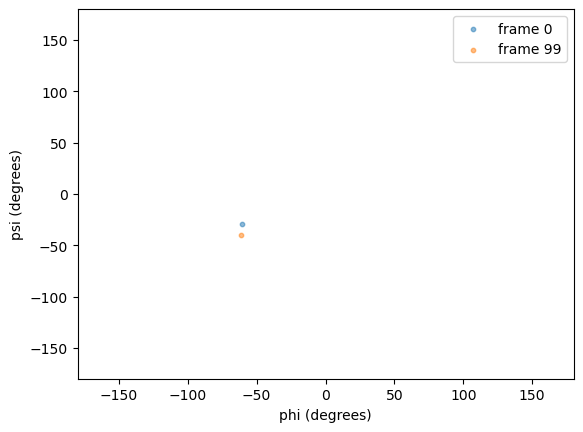

In [8]:
frames = [0, len(u.trajectory) - 1]
fig, ax = plt.subplots()

for f in frames:
    u.trajectory[f]
    protein = u.select_atoms("protein")

    rama = Ramachandran(protein).run()
    angles = rama.results.angles[f]

    phi = ((angles[:, 0] + 180) % 360) - 180
    psi = ((angles[:, 1] + 180) % 360) - 180

    ax.scatter(phi, psi, s=10, label=f"frame {f}", alpha=0.5)

ax.set_xlim(-180, 180)
ax.set_ylim(-180, 180)
ax.set_xlabel("phi (degrees)")
ax.set_ylabel("psi (degrees)")
ax.legend()

plt.show()

We can also conduct more detailed analysis, such as the distance between the Cα atoms of two residues. Define the residues by their segid (= chain ID) and residue id. Double check the residue name with the printed residue information!

<AtomGroup [<Atom 5: CA of type C of resname GLY, resid 1 and segid A and altLoc >]> <AtomGroup [<Atom 19: CA of type C of resname GLY, resid 3 and segid A and altLoc >]>


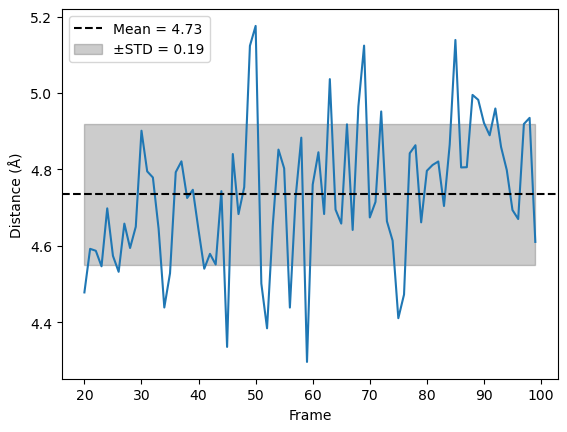

In [9]:
res1 = u.select_atoms("segid A and resid 1 and name CA")
res2 = u.select_atoms("segid A and resid 3 and name CA")

print(res1, res2)

dist = []
for ts in u.trajectory[start_frame:]:
    dist.append(distance_array(res1.positions, res2.positions)[0, 0])

dist = np.array(dist)
mean = dist.mean()
std = dist.std()

plt.plot(range(start_frame, start_frame + len(dist)), dist)
plt.axhline(mean, color="black", ls="--", label=f"Mean = {mean:.2f}")
plt.fill_between(
    range(start_frame, start_frame + len(dist)),
    mean - std,
    mean + std,
    color="black",
    alpha=0.2,
    label=f"±STD = {std:.2f}",
)

plt.xlabel("Frame")
plt.ylabel("Distance (Å)")
plt.legend()
plt.show()